In [50]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm

In [51]:
from pathlib import Path

yields_csv_dir = Path("Bond_Research") / "yields_csv"

files = {
    "Germany": "bund_uniform.csv",
    "Austria": "austria_uniform.csv",
    "Belgium": "belgium_uniform.csv",
    "France": "france_uniform.csv",
    "Ireland": "ireland_uniform.csv",
    "Italy": "italy_uniform.csv",
    "Netherlands": "netherlands_uniform.csv",
    "Portugal": "portugal_uniform.csv",
    "Spain": "spain_uniform.csv",
    "Greece": "greece_uniform.csv"
}

dfs = []

for country, file in files.items():

    temp = pd.read_csv(yields_csv_dir / file)

    temp["Country"] = country

    dfs.append(temp)

bond_df = pd.concat(dfs, ignore_index=True)

In [52]:
bond_df = bond_df[
    ["Date", "Country", "Maturity", "Yield"]
]

bond_df["Date"] = pd.to_datetime(
    bond_df["Date"],
    format="mixed"
)

bond_df["Yield"] = pd.to_numeric(
    bond_df["Yield"],
    errors="coerce"
)

In [53]:
bund = (
    bond_df[
        bond_df["Country"] == "Germany"
    ]
    [["Date", "Maturity", "Yield"]]
    .rename(
        columns={"Yield": "BundYield"}
    )
)
bund.head()

,Date,Maturity,BundYield
0,2026-09-25,2Y,3.274
1,2026-09-25,5Y,3.409
2,2026-09-25,10Y,3.600
3,2026-09-24,2Y,3.321
4,2026-09-24,5Y,3.437


In [54]:
bond_df = bond_df.merge(
    bund,
    on=["Date", "Maturity"],
    how="left"
)

In [55]:
bond_df["Spread"] = (
    bond_df["Yield"]
    - bond_df["BundYield"]
)
bond_df.info()
bond_df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 216415 entries, 0 to 216414
Data columns (total 6 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   Date       216415 non-null  datetime64[us]
 1   Country    216415 non-null  str           
 2   Maturity   216415 non-null  str           
 3   Yield      207940 non-null  float64       
 4   BundYield  212617 non-null  float64       
 5   Spread     204280 non-null  float64       
dtypes: datetime64[us](1), float64(3), str(2)
memory usage: 11.8 MB


,Date,Yield,BundYield,Spread
count,216415,207940.000000,212617.000000,204280.000000
mean,2012-11-07 12:43:04.833768,3.755845,1.970035,1.846651
min,1999-01-01 00:00:00,-1.014000,-1.014000,-1.308000
25%,2005-12-05 00:00:00,0.833000,0.171000,0.043000
50%,2012-11-07 00:00:00,2.807000,2.242000,0.217000
75%,2019-10-11 00:00:00,4.041000,3.463000,0.666000
max,2026-09-25 00:00:00,230.370000,5.644000,230.222000
std,NaN,13.625375,1.810887,13.594149


In [56]:
bond_df.loc[
    bond_df["Yield"].idxmax()
]

Date         2012-03-07 00:00:00
Country                   Greece
Maturity                      2Y
Yield                     230.37
BundYield                  0.148
Spread                   230.222
Name: 205048, dtype: object

note that greece is responsible for the largest spread. probably related to the Greek financial crisis.

# EDA (excluding Greece)

In [57]:
eda_df = bond_df[
    bond_df["Country"] != "Greece"
].copy()

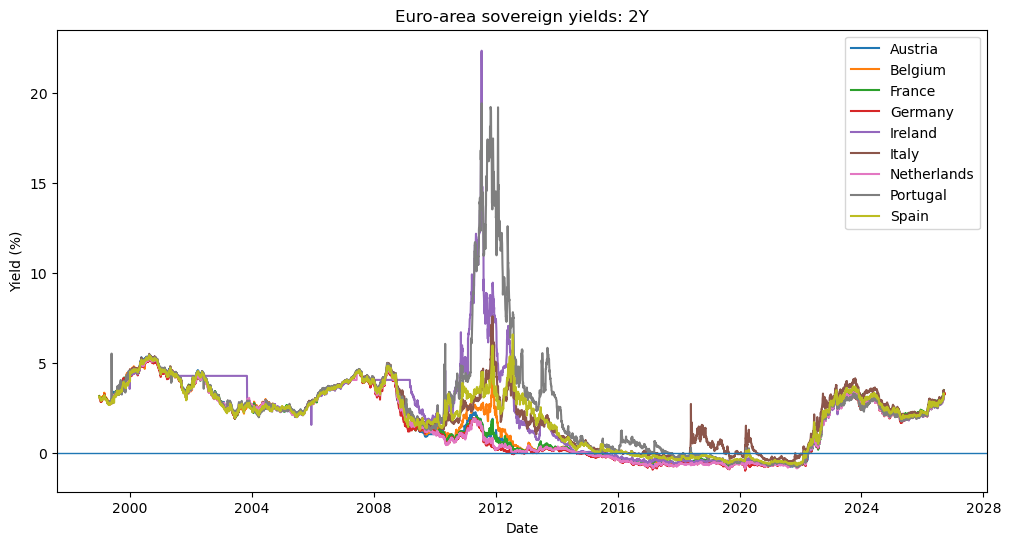

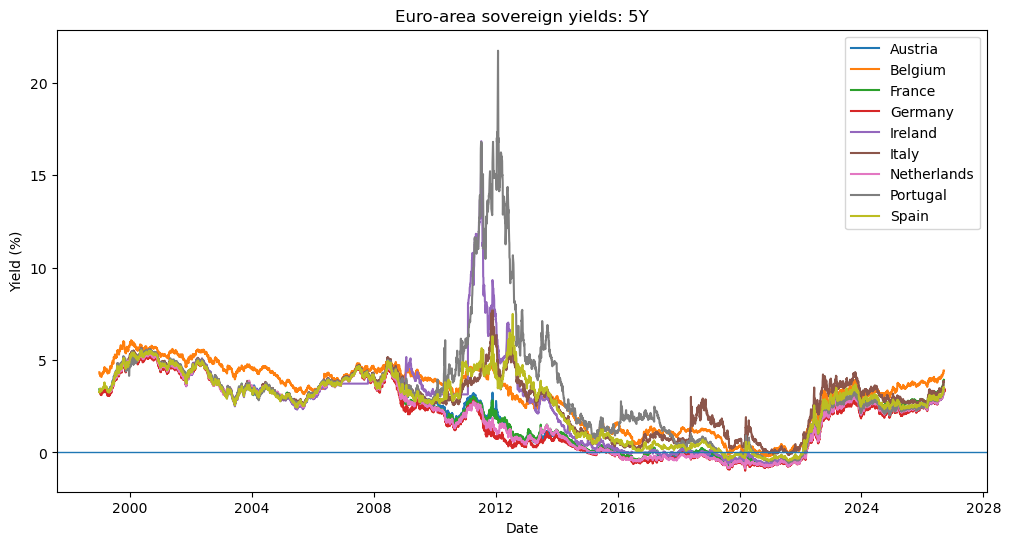

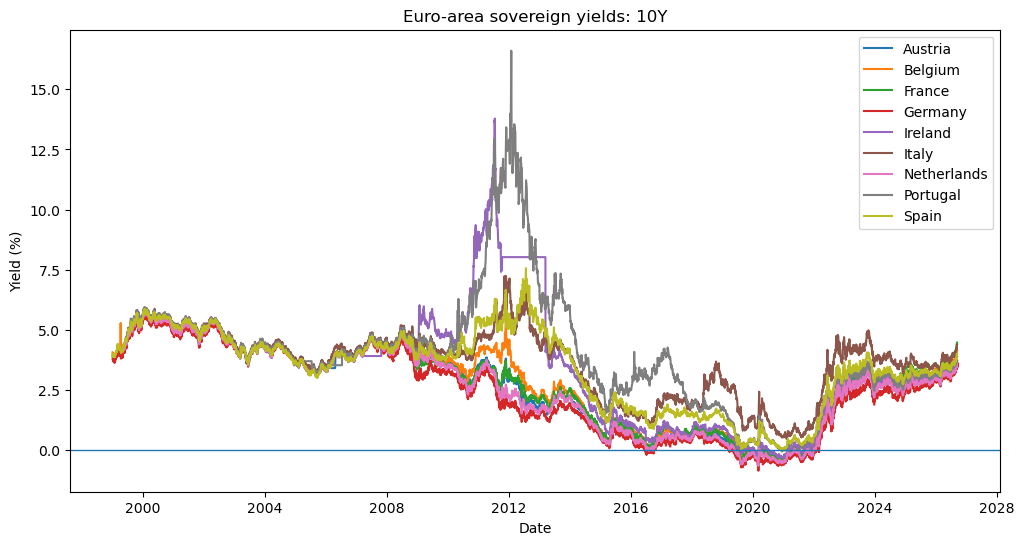

In [58]:
import matplotlib.pyplot as plt

for maturity in ["2Y", "5Y", "10Y"]:
    temp = eda_df[eda_df["Maturity"] == maturity]

    pivot = temp.pivot(
        index="Date",
        columns="Country",
        values="Yield"
    )

    plt.figure(figsize=(12, 6))

    for country in pivot.columns:
        plt.plot(
            pivot.index,
            pivot[country],
            label=country
        )

    plt.axhline(0, linewidth=1)
    plt.title(f"Euro-area sovereign yields: {maturity}")
    plt.xlabel("Date")
    plt.ylabel("Yield (%)")
    plt.legend()
    plt.show()

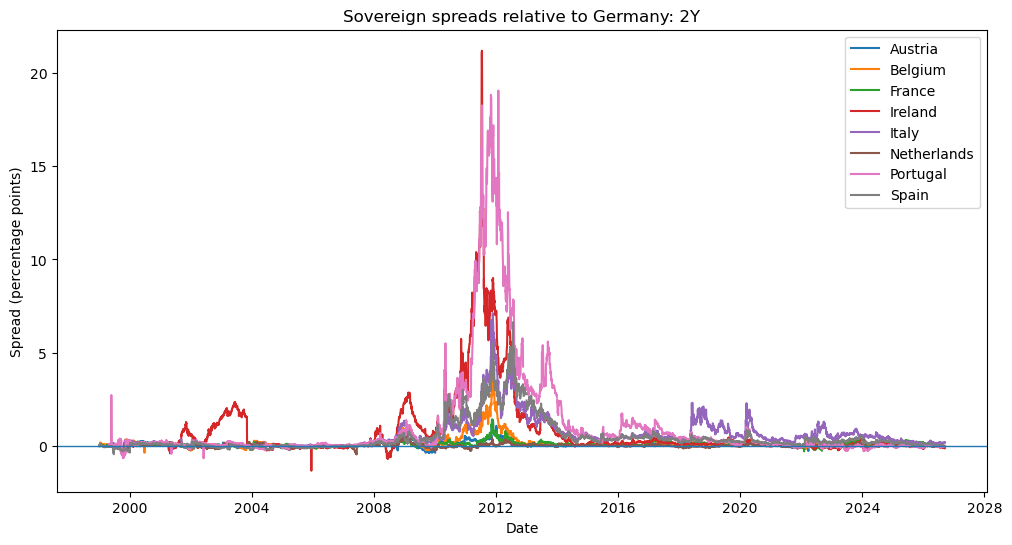

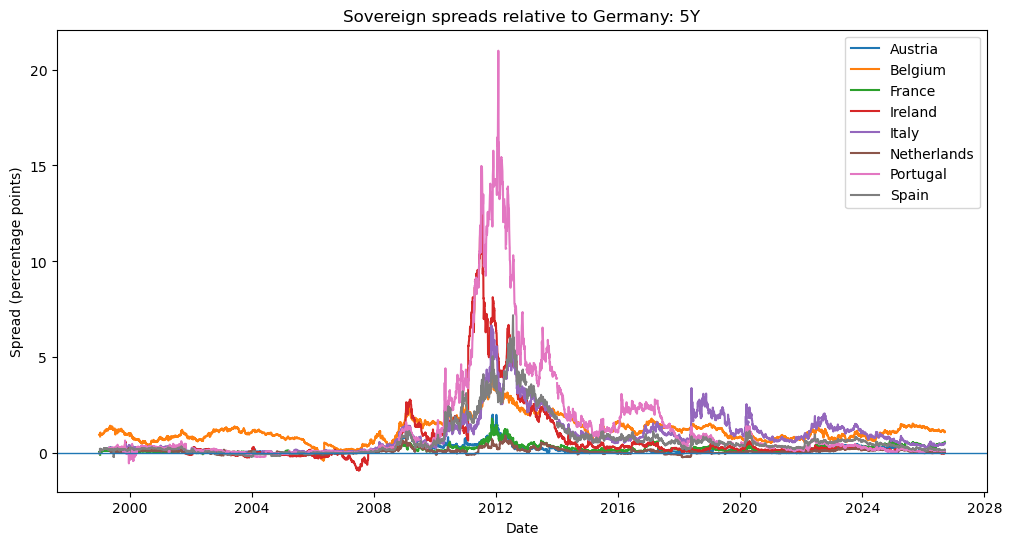

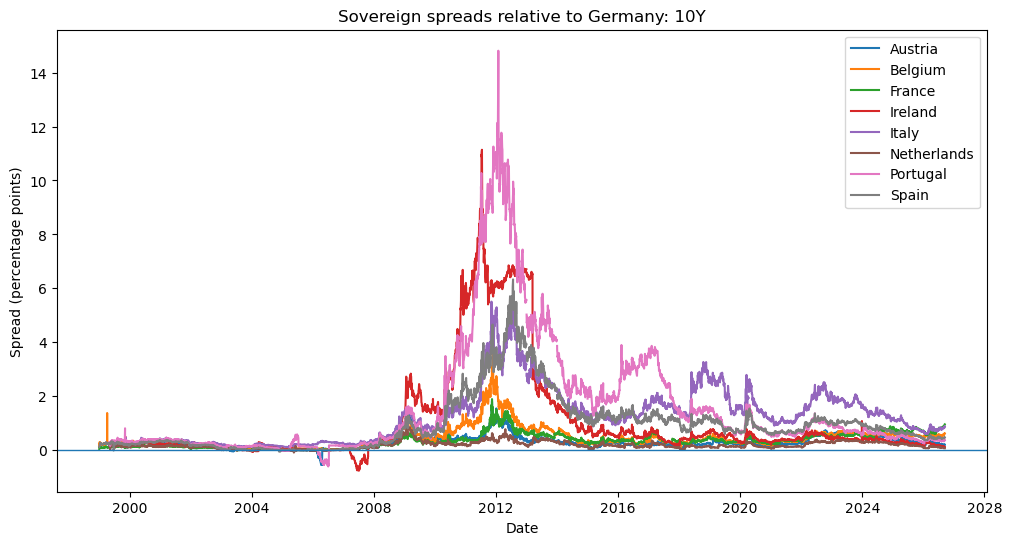

In [59]:
spread_df = eda_df[
    eda_df["Country"] != "Germany"
].copy()

for maturity in ["2Y", "5Y", "10Y"]:
    temp = spread_df[
        spread_df["Maturity"] == maturity
    ]

    pivot = temp.pivot(
        index="Date",
        columns="Country",
        values="Spread"
    )

    plt.figure(figsize=(12, 6))

    for country in pivot.columns:
        plt.plot(
            pivot.index,
            pivot[country],
            label=country
        )

    plt.axhline(0, linewidth=1)

    plt.title(
        f"Sovereign spreads relative to Germany: {maturity}"
    )
    plt.xlabel("Date")
    plt.ylabel("Spread (percentage points)")
    plt.legend()
    plt.show()

In [60]:
summary = (
    bond_df
    .groupby(["Country", "Maturity"])
    ["Yield"]
    .agg([
        "count",
        "mean",
        "std",
        "min",
        "median",
        "max"
    ])
)

summary

count       mean        std    min  median      max
Country     Maturity                                                     
Austria     10Y        7140   2.710503   1.743961 -0.485  3.0355    5.879
            2Y         7140   1.651303   1.795707 -0.865  1.9610    5.442
            5Y         7140   2.112692   1.807652 -0.758  2.5385    5.602
Belgium     10Y        7227   2.880024   1.726939 -0.436  3.2850    5.923
            2Y         7227   1.728707   1.774505 -0.833  2.1270    5.387
            5Y         7227   3.129382   1.671640 -0.214  3.4920    6.076
France      10Y        7227   2.772468   1.661648 -0.439  3.1940    5.758
            2Y         7227   1.671014   1.761380 -0.837  1.9250    5.352
            5Y         7227   2.138194   1.735432 -0.798  2.6030    5.427
Germany     10Y        7098   2.430355   1.754862 -0.858  2.6060    5.644
            2Y         7091   1.566449   1.778564 -1.014  1.8240    5.300
            5Y         7097   1.917713   1.792907 -0.991  2.2600    5.278
Greece      10Y        5097   6.683144   5.834408  0.534  4.6290   33.702
            2Y         5097  39.800942  75.402701 -0.533  3.3360  230.370
            5Y         5097  11.790440  16.385459 -0.251  4.1180   57.371
Ireland     10Y        7010   3.430631   2.370873 -0.334  3.4615   13.786
            2Y         7010   2.295327   2.398676 -0.743  2.3465   22.362
            5Y         7010   2.612691   2.264901 -0.660  2.8395   16.849
Italy       10Y        7010   3.617372   1.413001  0.455  3.9715    7.244
            2Y         7010   2.135019   1.631839 -0.521  2.2945    7.583
            5Y         7010   2.838963   1.551857 -0.126  3.1020    7.703
Netherlands 10Y        7140   2.594411   1.744227 -0.652  2.8180    5.816
            2Y         7140   1.578719   1.786364 -0.901  1.8270    5.345
            5Y         7140   2.006171   1.801075 -0.868  2.3625    5.455
Portugal    10Y        7140   3.991844   2.363639 -0.059  3.7585   16.605
            2Y         7140   2.630978   2.842102 -0.814  2.4910   19.436
            5Y         7140   3.354110   2.861599 -0.546  3.0350   21.748
Spain       10Y        7227   3.367445   1.618380 -0.019  3.7330    7.566
            2Y         7227   2.052623   1.678131 -0.694  2.3680    6.571
            5Y         7227   2.639277   1.704640 -0.457  2.9910    7.498

In [61]:
spread_summary = (
    bond_df[
        bond_df["Country"] != "Germany"
    ]
    .groupby(["Country", "Maturity"])
    ["Spread"]
    .agg([
        "count",
        "mean",
        "std",
        "min",
        "median",
        "max"
    ])
)

spread_summary

count       mean        std    min  median      max
Country     Maturity                                                     
Austria     10Y        7003   0.298925   0.236918 -0.545   0.255    1.808
            2Y         6996   0.104138   0.152843 -0.358   0.072    1.420
            5Y         7003   0.212066   0.232783 -0.149   0.160    2.010
Belgium     10Y        7089   0.451107   0.392202 -0.035   0.352    3.554
            2Y         7082   0.165446   0.350954 -0.345   0.084    4.533
            5Y         7088   1.213610   0.637568 -0.383   1.125    4.532
France      10Y        7089   0.343006   0.266010 -0.014   0.317    1.892
            2Y         7082   0.107500   0.132348 -0.270   0.080    1.448
            5Y         7088   0.221616   0.213145 -0.078   0.169    1.809
Greece      10Y        4998   5.059688   5.863220  0.200   2.648   31.903
            2Y         4991  38.623553  75.432175 -0.313   1.807  230.222
            5Y         4998  10.672767  16.664517  0.097   2.420   56.602
Ireland     10Y        6873   1.064227   1.826609 -0.766   0.397   11.140
            2Y         6866   0.782582   1.840065 -1.308   0.127   21.173
            5Y         6873   0.754221   1.678714 -0.907   0.230   14.939
Italy       10Y        6873   1.249206   0.988913  0.035   1.166    5.507
            2Y         6866   0.619977   0.813473 -0.177   0.397    7.127
            5Y         6873   0.979472   1.008626 -0.065   0.741    6.664
Netherlands 10Y        7003   0.182490   0.131897 -0.094   0.154    0.865
            2Y         6996   0.031514   0.089549 -0.433   0.028    0.500
            5Y         7003   0.105580   0.135723 -0.214   0.079    0.930
Portugal    10Y        7003   1.582568   2.223288 -0.608   0.666   14.814
            2Y         6996   1.084519   2.679800 -0.642   0.181   19.040
            5Y         7003   1.457363   2.780376 -0.524   0.384   20.979
Spain       10Y        7089   0.938496   1.009601 -0.059   0.715    6.331
            2Y         7082   0.486875   0.845640 -0.423   0.221    6.643
            5Y         7088   0.723737   1.013809 -0.195   0.421    7.196

In [62]:
missing = (
    bond_df
    .groupby(["Country", "Maturity"])
    ["Yield"]
    .agg(
        total="size",
        available="count"
    )
)

missing["missing"] = (
    missing["total"] - missing["available"]
)

missing["missing_pct"] = (
    100 * missing["missing"] / missing["total"]
)

missing

total  available  missing  missing_pct
Country     Maturity                                        
Austria     10Y        7227       7140       87     1.203819
            2Y         7227       7140       87     1.203819
            5Y         7227       7140       87     1.203819
Belgium     10Y        7227       7227        0     0.000000
            2Y         7227       7227        0     0.000000
            5Y         7227       7227        0     0.000000
France      10Y        7227       7227        0     0.000000
            2Y         7227       7227        0     0.000000
            5Y         7227       7227        0     0.000000
Germany     10Y        7098       7098        0     0.000000
            2Y         7091       7091        0     0.000000
            5Y         7097       7097        0     0.000000
Greece      10Y        7227       5097     2130    29.472810
            2Y         7227       5097     2130    29.472810
            5Y         7227       5097     2130    29.472810
Ireland     10Y        7227       7010      217     3.002629
            2Y         7227       7010      217     3.002629
            5Y         7227       7010      217     3.002629
Italy       10Y        7227       7010      217     3.002629
            2Y         7227       7010      217     3.002629
            5Y         7227       7010      217     3.002629
Netherlands 10Y        7227       7140       87     1.203819
            2Y         7227       7140       87     1.203819
            5Y         7227       7140       87     1.203819
Portugal    10Y        7227       7140       87     1.203819
            2Y         7227       7140       87     1.203819
            5Y         7227       7140       87     1.203819
Spain       10Y        7227       7227        0     0.000000
            2Y         7227       7227        0     0.000000
            5Y         7227       7227        0     0.000000

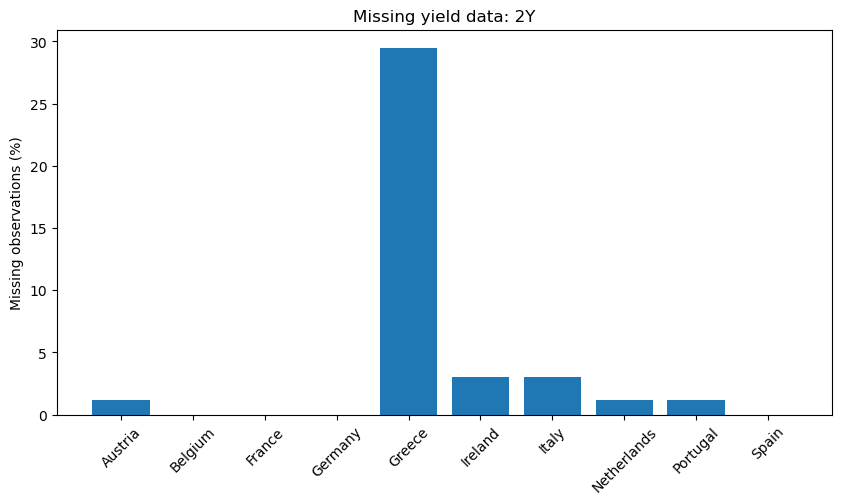

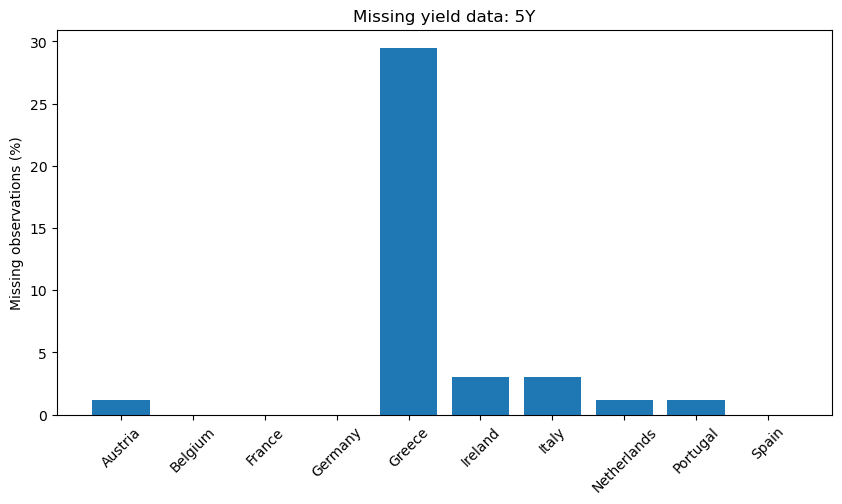

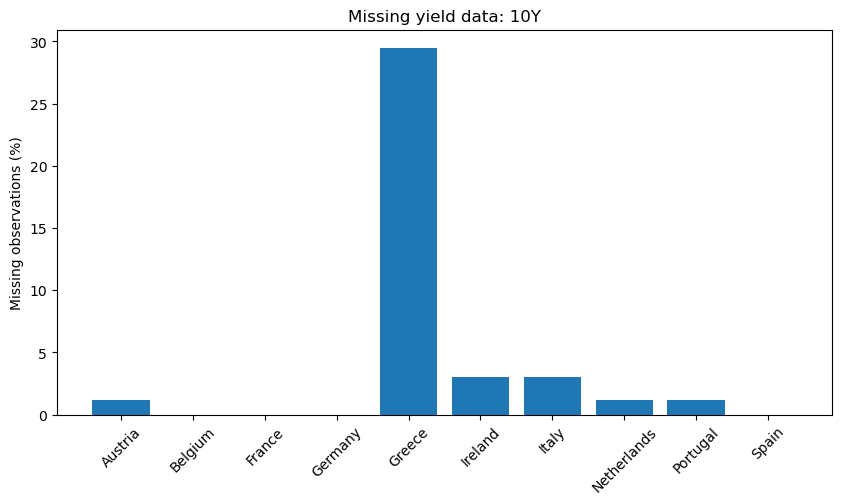

In [63]:
missing_plot = (
    missing
    .reset_index()
)

for maturity in ["2Y", "5Y", "10Y"]:
    temp = missing_plot[
        missing_plot["Maturity"] == maturity
    ]

    plt.figure(figsize=(10, 5))

    plt.bar(
        temp["Country"],
        temp["missing_pct"]
    )

    plt.xticks(rotation=45)
    plt.ylabel("Missing observations (%)")
    plt.title(f"Missing yield data: {maturity}")
    plt.show()

In [65]:
bond_df = bond_df.sort_values(
    ["Country", "Maturity", "Date"]
)

bond_df["YieldChange"] = (
    bond_df
    .groupby(["Country", "Maturity"])
    ["Yield"]
    .diff()
)

bond_df["SpreadChange"] = (
    bond_df
    .groupby(["Country", "Maturity"])
    ["Spread"]
    .diff()
)

bond_df[
    ["YieldChange", "SpreadChange"]
].describe()

,YieldChange,SpreadChange
count,207910.000000,201802.000000
mean,-0.000024,0.000075
std,0.470946,0.476131
min,-185.619000,-185.616000
25%,-0.023000,-0.007000
50%,0.000000,0.000000
75%,0.022000,0.006000
max,27.596000,27.620000


In [66]:
bond_df.nlargest(
    20,
    "YieldChange"
)[
    [
        "Date",
        "Country",
        "Maturity",
        "YieldChange"
    ]
]

,Date,Country,Maturity,YieldChange
204922,2012-01-09,Greece,2Y,27.596
204961,2012-01-26,Greece,2Y,23.939
205048,2012-03-07,Greece,2Y,22.751
205015,2012-02-21,Greece,2Y,18.198
207652,2015-07-06,Greece,2Y,16.087
207637,2015-06-29,Greece,2Y,15.713
205003,2012-02-15,Greece,2Y,13.719
205018,2012-02-22,Greece,2Y,13.208
204778,2011-11-02,Greece,2Y,11.340
204667,2011-09-12,Greece,2Y,10.548


In [67]:
bond_df.assign(
    abs_change=bond_df["YieldChange"].abs()
).nlargest(
    20,
    "abs_change"
)[
    [
        "Date",
        "Country",
        "Maturity",
        "YieldChange"
    ]
]

,Date,Country,Maturity,YieldChange
207505,2015-04-28,Greece,2Y,-185.619
206693,2014-04-14,Greece,5Y,-48.416
204922,2012-01-09,Greece,2Y,27.596
204964,2012-01-27,Greece,2Y,-24.343
204961,2012-01-26,Greece,2Y,23.939
207664,2015-07-10,Greece,2Y,-23.919
205048,2012-03-07,Greece,2Y,22.751
205015,2012-02-21,Greece,2Y,18.198
205012,2012-02-20,Greece,2Y,-17.662
207652,2015-07-06,Greece,2Y,16.087


10Y Yield Analysis

In [68]:
yield_10y = (
    bond_df[
        bond_df["Maturity"] == "10Y"
    ]
    .pivot(
        index="Date",
        columns="Country",
        values="Yield"
    )
)

yield_10y.corr()

Country,Austria,Belgium,France,Germany,Greece,Ireland,Italy,Netherlands,Portugal,Spain
Country,,,,,,,,,,
Austria,1.000000,0.991500,0.995620,0.990887,0.188713,0.698706,0.873220,0.997063,0.515477,0.863396
Belgium,0.991500,1.000000,0.991536,0.974767,0.308143,0.766959,0.913168,0.984571,0.604416,0.906213
France,0.995620,0.991536,1.000000,0.989383,0.197035,0.698993,0.876473,0.994077,0.524407,0.869716
Germany,0.990887,0.974767,0.989383,1.000000,0.114118,0.644946,0.824024,0.997200,0.450636,0.823983
Greece,0.188713,0.308143,0.197035,0.114118,1.000000,0.688893,0.538154,0.146305,0.883407,0.612913
Ireland,0.698706,0.766959,0.698993,0.644946,0.688893,1.000000,0.858913,0.673595,0.893533,0.917236
Italy,0.873220,0.913168,0.876473,0.824024,0.538154,0.858913,1.000000,0.850306,0.779804,0.962558
Netherlands,0.997063,0.984571,0.994077,0.997200,0.146305,0.673595,0.850306,1.000000,0.484135,0.847274
Portugal,0.515477,0.604416,0.524407,0.450636,0.883407,0.893533,0.779804,0.484135,1.000000,0.830191


In [69]:
change_10y = yield_10y.diff()

change_10y.corr()

Country,Austria,Belgium,France,Germany,Greece,Ireland,Italy,Netherlands,Portugal,Spain
Country,,,,,,,,,,
Austria,1.000000,0.866746,0.920128,0.879778,0.056845,0.419665,0.568055,0.897031,0.328883,0.605589
Belgium,0.866746,1.000000,0.832647,0.728488,0.126694,0.463682,0.682791,0.828941,0.396327,0.655510
France,0.920128,0.832647,1.000000,0.883881,0.063025,0.433356,0.628626,0.906751,0.348822,0.646625
Germany,0.879778,0.728488,0.883881,1.000000,-0.029249,0.372443,0.424859,0.947669,0.264126,0.484650
Greece,0.056845,0.126694,0.063025,-0.029249,1.000000,0.158032,0.214823,0.018722,0.257481,0.214087
Ireland,0.419665,0.463682,0.433356,0.372443,0.158032,1.000000,0.406142,0.406486,0.393293,0.431256
Italy,0.568055,0.682791,0.628626,0.424859,0.214823,0.406142,1.000000,0.501609,0.468182,0.831215
Netherlands,0.897031,0.828941,0.906751,0.947669,0.018722,0.406486,0.501609,1.000000,0.299281,0.547710
Portugal,0.328883,0.396327,0.348822,0.264126,0.257481,0.393293,0.468182,0.299281,1.000000,0.490875


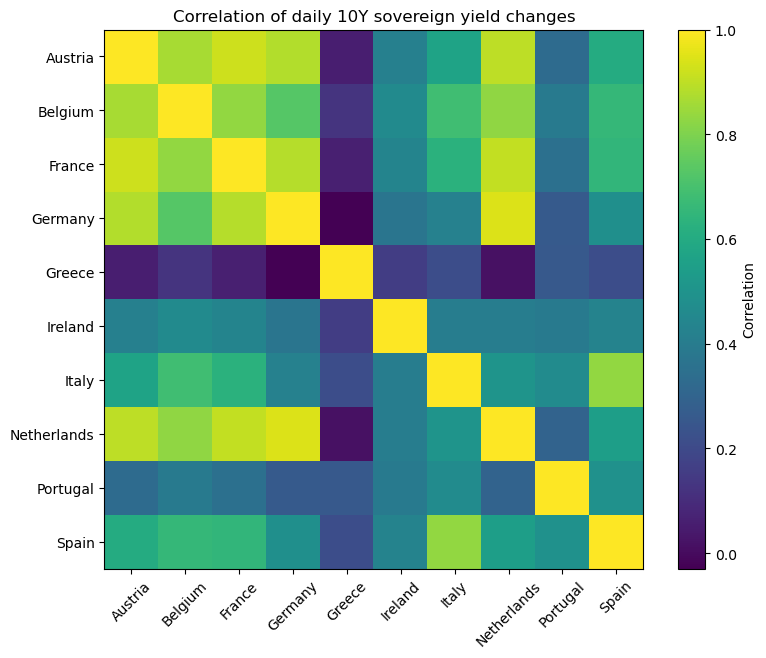

In [70]:
corr = change_10y.corr()

plt.figure(figsize=(9, 7))
plt.imshow(corr)

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=45
)

plt.yticks(
    range(len(corr.index)),
    corr.index
)

plt.colorbar(
    label="Correlation"
)

plt.title(
    "Correlation of daily 10Y sovereign yield changes"
)

plt.show()

In [71]:
core = [
    "France",
    "Netherlands",
    "Austria",
    "Belgium"
]

periphery = [
    "Italy",
    "Spain",
    "Portugal",
    "Ireland"
]

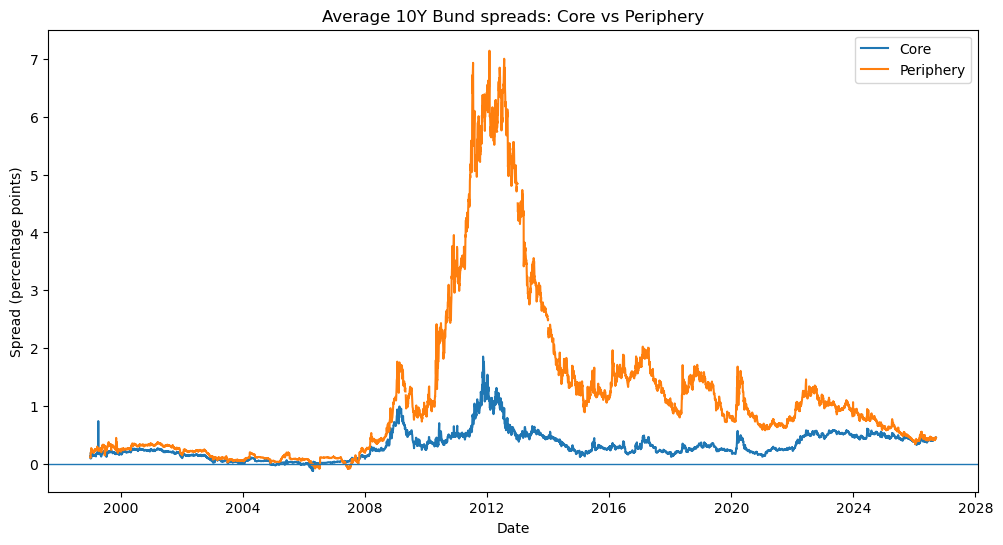

In [72]:
temp = bond_df[
    (bond_df["Maturity"] == "10Y") &
    (bond_df["Country"] != "Germany") &
    (bond_df["Country"] != "Greece")
].copy()

temp["Group"] = temp["Country"].apply(
    lambda x:
        "Core" if x in core
        else "Periphery"
)

group_spreads = (
    temp
    .groupby(["Date", "Group"])
    ["Spread"]
    .mean()
    .unstack()
)

plt.figure(figsize=(12, 6))

plt.plot(
    group_spreads.index,
    group_spreads["Core"],
    label="Core"
)

plt.plot(
    group_spreads.index,
    group_spreads["Periphery"],
    label="Periphery"
)

plt.axhline(0, linewidth=1)

plt.title(
    "Average 10Y Bund spreads: Core vs Periphery"
)

plt.ylabel("Spread (percentage points)")
plt.xlabel("Date")
plt.legend()

plt.show()